## Running Accelerator Toolbox in a simplified view.

*Sverker Werin 2026*

IPAC 2026 version


In the Load and initialize section **Accelerator Toolbox** is installed the first time you run the script (once per session).

1. Start by running the complete Notebook (Windows: ctrl-F9 or from the menu: >Run all or >Run>Run all. On a mobile the menu may be hidden behind a "down arrow")
2. Open a module by pressing the ">" beside the title or press "cells hidden" (if you open the code, double-click the title to close)
3. Calculations are made by push-buttons
4. To edit or add a new lattice you need to open the "User lattices" cell in the "Latticemodule" (double-click the title. Double-click the title to close)
5. Running a cell is normally not necessary (Run a cell by pressing the arrow at the title or press shift-enter)

More instructions on: https://github.com/werin99/pyAT_interface


A template lattice is prepared by default "MAX I 550 MeV (template)". This is one cell of the MAX I storage ring.


In [223]:
#@title #Safe initialisation

# Run this cell once for this Jupyter notebook.
###############################################
# 240830 Seems to be fixed, it works now
# 220927 Printing the complete matrix stopped working with AT 0.3.0.
# Quick fix: load lower version of AT.

#211025 Bug fixes with running AT 0.2.1
# Explicitly state PassMethod as default method changed.
# Optics calculation uses a lattice object instead of the lattice.

# Install Accelerator toolbox, only for Google Colab
try:
  import at
except ImportError as e:
  print("Installing accelerator-toolbox")
  !pip install accelerator-toolbox>=0.3.0
  #!pip install 'accelerator-toolbox>=0.1.0,<0.3.0' # Force old version

# load libraries

import numpy as np
import at
import matplotlib.pyplot as plt
import pandas as pd
from ipywidgets import interact
import ipywidgets as widgets
from IPython.display import display
from IPython.display import clear_output

# Setting default values
length=1

# Define a Class to carry each lattice data
class latticeClass:
  name='myLattice'
  elements=pd.DataFrame(
    {
    1: ['Drift_empty', 0.0,0,0],
    2: ['Drift_empty', 0.0,0,0]
    },
    index=['type','length','bending angle','K-value']
)

# Define a template lattice based on one achromat of the MAX I 550 MeV ring
template=latticeClass()

template.name="MAX I 550 MeV (template)"
template.elements=pd.DataFrame(
    {
    1: ['Drift', 1.295, 0, 0],
    2: ['Quad',0.21,0,4.25],
    3: ['Drift',	0.265,	0,	0],
    4: ['Quad',	0.21,	0	,-3.02],
    5: ['Drift',	0.27025,	0,	0],
    6: ['Rbend',	0.9425,	0.785398,	0],
    7: ['Drift',	0.6523,	0	,0],
    8: ['Quad',	0.41,	0,	4.19],
    9: ['Drift',	0.6523,	0,	3],
    10: ['Rbend',	0.9425,	0.785398,	0],
    11: ['Drift',	0.27025,	0,	0],
    12: ['Quad',	0.21,	0,	-3.02],
    13: ['Drift',	0.265,	0,	0],
    14: ['Quad',	0.21,	0,	4.25],
    15: ['Drift',	1.295,	0,	0],
    },
    index=['type','length','bending angle','K-value']
)

# Define functions

# Plot the betatron tune space
def tunespace(tune,x_in,y_in,order):
    # Mark the tune position
    plt.scatter(tune[0],tune[1],marker='o',s=100)

    # Define plot limits
    x_off=x_in[0]
    x_min=x_in[0]-x_off
    x_max=x_in[1]-x_off

    y_off=y_in[0]
    y_min=y_in[0]-y_off
    y_max=y_in[1]-y_off

    F_0=np.maximum(x_max-x_min, y_max-y_min)

    # Restrict to 4th order
    if (order>4):
        print('Maximum order 4')
        return

    # Line type for different order
    line=['-b','--r','-.b',':g']

    # Generate the resonance lines
    for n in range(1,order+1):
        ll=line[n-1] # select line type

        for i in range(0,n+1):
            a=i
            b=n-a
            for F in range(-F_0*n,F_0*n):
                # print('F,a, b',F,a,b)
                if (a != 0):
                    xp=[(F-b*y_min)/a+x_off,(F-b*y_max)/a+x_off]
                    plt.plot(xp,y_in,ll)
                    xp=[(F+b*y_min)/a+x_off,(F+b*y_max)/a+x_off]
                    plt.plot(xp,y_in,ll)



                else:
                    yp=[F/b+y_off,F/b+y_off]
                    plt.plot(x_in,yp,ll)


    axes=plt.gca()
    axes.set_xlim(x_in)
    axes.set_ylim(y_in)
    axes.set_xlabel('Horisontal tune')
    axes.set_ylabel('Vertical tune')
    axes.set_title('Tune diagram (Blue dot = Working point)')

    plt.show()

    return



Lattices=[template] # Do NOT change this line!
#
# Copy or change from HERE
# After adding/changing the lattice, re-run the notebook! (alt+F9 or "Run all")
#
myNewLattice=latticeClass()
myNewLattice.name='SESAME 2.5 GeV'
myNewLattice.elements = pd.DataFrame(
{
1:  ['Sext', 0.1,    0.0,   7.6],
2:  ['Drift',     0.15,   0.0,   0.0],
3:  ['Quad',0.1,    0.0,   -0.91],
4:  ['Drift',     0.15,   0.0,   0.0],
5:  ['Quad',0.3,    0.0,   1.98],
6:  ['Drift',     0.15,   0.0,   0.0],
7:  ['Sext', 0.1,    0.0,  -13.1],
8:  ['Drift',     0.28,   0.0,   0.0],

9:  ['Sbend',    0.5625, 2*np.pi/(4*16), -0.335],
10: ['Sbend',    0.5625, 2*np.pi/(4*16), -0.335],
11: ['Sbend',    0.5625, 2*np.pi/(4*16), -0.335],
12: ['Sbend',    0.5625, 2*np.pi/(4*16), -0.335],

13: ['Drift',     0.28,   0.0,   0.0],
14: ['Sext', 0.1,    0.0,   7.6],
15: ['Drift',     0.15,   0.0,   0.0],
16: ['Quad',0.3,    0.0,   1.98],
17: ['Drift',     0.15,   0.0,   0.0],
18: ['Quad',0.1,    0.0,  -0.91],
19: ['Drift',     0.15,   0.0,   0.0],
20: ['Sext', 0.1,    0.0,  -13.1],

21: ['Drift',     2.52,   0.0,   0.0],

22: ['Sext', 0.1,    0.0,   7.6],
23: ['Drift',     0.15,   0.0,   0.0],
24: ['Quad',0.1,    0.0,  -0.91],
25: ['Drift',     0.15,   0.0,   0.0],
26: ['Quad',0.3,    0.0,   1.98],
27: ['Drift',     0.15,   0.0,   0.0],
28: ['Sext', 0.1,    0.0,  -13.1],
29: ['Drift',     0.28,   0.0,   0.0],

30: ['Sbend',    0.5625, 2*np.pi/(4*16), -0.335],
31: ['Sbend',    0.5625, 2*np.pi/(4*16), -0.335],
32: ['Sbend',    0.5625, 2*np.pi/(4*16), -0.335],
33: ['Sbend',    0.5625, 2*np.pi/(4*16), -0.335],

34: ['Drift',     0.28,   0.0,   0.0],
35: ['Sext', 0.1,    0.0,   7.6],
36: ['Drift',     0.15,   0.0,   0.0],
37: ['Quad',0.3,    0.0,   1.98],
38: ['Drift',     0.15,   0.0,   0.0],
39: ['Quad',0.1,    0.0,  -0.91],
40: ['Drift',     0.15,   0.0,   0.0],
41: ['Sext', 0.1,    0.0,  -13.1],
42: ['Drift',     4.3,    0.0,   0.0]
},
index=['type','length','bending angle','K-value']
)
Lattices.append(myNewLattice) # Add the lattice to the list of lattices
#
# Copy and change UNTIL here
#

#
# Below is a lattice of the 3 GeV ring at MAX IV Laboratory (one achromat)
#
miv3gev=latticeClass()
miv3gev.name='MAX IV 3GeV'
miv3gev.elements = pd.DataFrame(
  {
  1: ['Drift', 2.5,0,0],
  2: ['Drift', 0.175,0,0],
  3: ['Quad', 0.25 ,0,3.533676],
  4: ['Drift', 0.225,0,0],
  5: ['Quad', 0.25 ,0,-2.23958],
  6: ['Drift', 0.006,0,0],
  7: ['Sbend', 0.75432, 1.5*(np.pi/180), -0.54525],
  8: ['Drift', 0.46268,0,0],
  9: ['Drift', 1.302,0,0],
  10: ['Quad', 0.55,0, 2.061576],
  11: ['Drift', 0.51311,0,0],
  12: ['Sbend', 1.22387, 3.0*(np.pi/180), -0.70480],
  13: ['Drift', 0.51311,0,0],
  14: ['Quad', 0.55 ,0,2.202441],
  15: ['Drift', 0.51311,0,0],
  16: ['Sbend', 1.22378, 3.0*(np.pi/180), -0.70408],
  17: ['Drift', 0.51311,0,0],
  18: ['Quad', 0.55 ,0,2.202441],
  19: ['Drift', 0.51311,0,0],
  20: ['Sbend', 1.22378, 3.0*(np.pi/180), -0.70408],
  21: ['Drift', 0.51311,0,0],
  22: ['Quad', 0.55 ,0,2.202441],
  23: ['Drift', 0.51311,0,0],
  24: ['Sbend', 1.22378, 3.0*(np.pi/180), -0.70408],
  25: ['Drift', 0.51311,0,0],
  26: ['Quad', 0.55,0, 2.202441],
  27: ['Drift', 0.51311,0,0],
  28: ['Sbend', 1.22378, 3.0*(np.pi/180), -0.70408],
  29: ['Drift', 0.51311,0,0],
  30: ['Quad', 0.55 ,0,2.061576],
  31: ['Drift', 1.302,0,0],
  32: ['Drift', 0.46268,0,0],
  33: ['Sbend', 0.75432 ,1.5*(np.pi/180) ,-0.54525],
  34: ['Drift', 0.006,0,0],
  35: ['Quad', 0.25 ,0,-2.23958],
  36: ['Drift', 0.225,0,0],
  37: ['Quad', 0.25 ,0, 3.533676],
  38: ['Drift', 0.175,0,0],
  39: ['Drift', 2.5,0,0]
  },
  index=['type','length','bending angle','K-value']
)
Lattices.append(miv3gev) # Add the lattice to the list of lattices


In [224]:
import ipywidgets as widgets
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np

options=[]
for i in range(len(Lattices)): # Find all lattices
    options.append(Lattices[i].name)

latticeSelect=widgets.RadioButtons(
    options=options,
    description='Select lattice:',
    disabled=False
)

# Select the periodicity of the lattice
period=widgets.IntText(
    value=1,
    description='Periodicity =',
    disabled=False
)

energy_widget=widgets.FloatText(
    value=3,
    description='Energy =',
    disabled=False
)

#@title ###Make the lattice
selectedLattice=options.index(latticeSelect.value)
button1L = widgets.Button(description="Make the Lattice")
output1L = widgets.Output()

display(button1L,output1L)
lattice=0
refpts=0

def on_button1L_clicked(b):
    with output1L:
        clear_output()

        global lattice, lattice_t, num_of_elem # make the data global
        selectedLattice=options.index(latticeSelect.value)

        lattice_in=Lattices[selectedLattice].elements # extract the elements
        lattice_t=lattice_in.transpose()
        elements=lattice_t.values

        num_of_elem=len(lattice_in.columns) # Number of elements in lattice

        # Add one zero length element at start
        lattice=[at.elements.Drift('start', 0.00000)]
        # Loop over the entries in the lattice and extract relevant data
        for i in range(0,num_of_elem):
            if elements[i][0]=='Drift':
                elem=at.elements.Drift('drift',elements[i][1])
            elif elements[i][0]=='Quad':
                K=elements[i][3]
                elem=at.elements.Quadrupole('quad',elements[i][1],K)
                elem.PassMethod='QuadLinearPass'
            elif elements[i][0]=='Rbend':
                angle=elements[i][2]
                K=elements[i][3]
                elem=at.elements.Bend('dip',elements[i][1],angle)
                elem.K=K
                elem.EntranceAngle=angle/2
                elem.ExitAngle=angle/2
                elem.PassMethod='BendLinearPass'
            elif elements[i][0]=='Sbend':
                angle=elements[i][2]
                K=elements[i][3]
                elem=at.elements.Bend('dip',elements[i][1],angle)
                elem.K=K
                elem.EntranceAngle=0
                elem.ExitAngle=0
                elem.PassMethod='BendLinearPass'
            elif elements[i][0]=='Sext':
                H=elements[i][3]
                elem=at.elements.Sextupole('sext',elements[i][1],H)

            # Add element to the lattice list
            lattice=lattice+ [elem]

        # Repeat the lattice (periodicity)
        lattice=lattice[1:num_of_elem+1]*period.value

        num_of_elem=len(lattice) # update length of lattice
        print('Lattice ready with',num_of_elem,'elements.')

        # Define an AT lattice object
        global THERING, length, refpts,s, optics,beta,disp
        THERING = at.lattice.Lattice(lattice, energy=energy_widget.value*1e9, periodicity=period.value)
        length = np.size(THERING)
        refpts = np.r_[0:length + 1] # reference points for calculations and plot
        s = at.lattice.get_s_pos(THERING) # physical s position of elements

        # Calculate and check if the lattice has a closed solution
        try:
            optics = at.physics.linopt(THERING,refpts=refpts, get_chrom=True)
            beta = optics[3]['beta']
            disp = optics[3]['dispersion']
            alpha = optics[3]['alpha']
            mu = optics[3]['mu']
            gamma = optics[3]['gamma']
        except ValueError:
            print("Oops!  That was not a valid lattice.  Try again...")

# Button to make the translation and basic optics check
button1L.on_click(on_button1L_clicked)


#@title ###Display the lattice
button1c = widgets.Button(description="Compact")
output1c = widgets.Output()

button1 = widgets.Button(description="Complete")
output1 = widgets.Output()

# Allow to clear the output as it can become long
button1b = widgets.Button(description="Clear output")
output1b = widgets.Output()

def on_button1_clicked(b):
    with output1:
        try:
            for i in range(0,num_of_elem):
                print(lattice[i])
        except NameError:
            print('No lattice defined')

def on_button1c_clicked(b):
    with output1:
        try:
            print(lattice_t)
        except NameError:
            print('No lattice defined')

def on_button1b_clicked(b):
    with output1:
        clear_output()

button1.on_click(on_button1_clicked)
button1c.on_click(on_button1c_clicked)
button1b.on_click(on_button1b_clicked)


def on_button_clicked4(b): # print the 4x4 transfer matric of a defined element
    with output4:
        clear_output()
        element=w1.value
        try:
            m66=at.find_elem_m66(lattice[element-1])

            print('Transfer matrix of element',element,' = ')
            print(m66[0:4,0:4])
        except TypeError:
            print('Error')
        except IndexError:
            print('There are only',length,' elements')

def on_button_clicked4b(b): # Print the transfer matrix of the complete lattice
    with output4b:
        clear_output()
        try:
            a=at.find_m44(THERING,0)
            print(a[0])
        except Exception as e:
            print(f'Error: {e}')


button4 = widgets.Button(description="Print matrix of")
output4 = widgets.Output()
button4.on_click(on_button_clicked4)

button4b = widgets.Button(description="Print the full lattice matrix")
output4b = widgets.Output()
button4b.on_click(on_button_clicked4b)

# Box to select which element
w1=widgets.BoundedIntText(
    value=1,min=1, step=1,
    description='Element:',
    disabled=False
)

single_element = widgets.HBox([button4,w1])

matrices_tab = widgets.VBox(
    [single_element, output4, button4b, output4b],
    layout=widgets.Layout(margin='5px 0px 15px 0px', justify_content='flex-start')
)

tab2 = widgets.HBox(
    [button1c, button1, button1b],
    layout=widgets.Layout(margin='5px 0px 15px 0px', justify_content='flex-start')
)

# --- NOWA SEKCJA: Przycisk i logika dla Lattice Geometry ---

geometry_canvas = widgets.Output(
    layout=widgets.Layout(margin='5px 10px 15px 0px', min_height='100px')
)

geometry_canvas2 = widgets.Output(
    layout=widgets.Layout(margin='5px 10px 15px 0px', min_height='100px')
)

button_geom = widgets.Button(
    description="Plot Geometry",
    button_style='info',
    icon='image'
)

def on_plot_geometry_clicked(b):
    # Najpierw sprawdzamy globalnie czy sieć w ogóle istnieje, żeby uniknąć błędów w obu canvasach
    if 'THERING' not in globals() or num_of_elem == 0:
        with geometry_canvas:
            clear_output(wait=True)
            print("No lattice defined yet. Please click 'Make the Lattice' first.")
        with geometry_canvas2:
            clear_output(wait=True)
        return

    # Wykres 1: Wbudowana funkcja AT
    with geometry_canvas:
        clear_output(wait=True)
        try:
            fig1 = plt.figure(figsize=(8, 4))
            THERING.plot_geometry()
            plt.show()
        except Exception as e:
            print(f"Error drawing AT geometry: {e}")

    # Wykres 2: Ręcznie rysowana geometria elementów
    with geometry_canvas2:
        clear_output(wait=True)
        try:
            # Define an array for coordinates of each element
            geometry=np.zeros((4,2*num_of_elem+2))

            for i in range(0,num_of_elem): # Loop the elements
                # make the s-axis with points at both entrance and exit of each element
                geometry[0,2*i]=geometry[0,2*i-1]
                geometry[0,2*i+1]=lattice[i].Length+geometry[0,2*i]

                # Set values for different element types
                if lattice[i].FamName == 'quad':
                    geometry[1,2*i]=1.5
                    geometry[1,2*i+1]=1.5
                    geometry[3,2*i]=lattice[i].K
                    geometry[3,2*i+1]=lattice[i].K
                elif lattice[i].FamName == 'dip':
                    geometry[1,2*i]=2
                    geometry[1,2*i+1]=2
                    geometry[3,2*i]=lattice[i].K
                    geometry[3,2*i+1]=lattice[i].K

            geometry[0,2*i+2]=geometry[0,2*i+1] # fix end point

            # Bezpieczne skalowanie wartości K (unikanie dzielenia przez zero jeśli max to 0)
            kMax=max(geometry[3,:])
            if kMax != 0:
                geometry[3,:]/=kMax

            fig2 = plt.figure(figsize=(8, 4)) # Dodano jawne tworzenie nowej figury dla porządku
            plt.plot(geometry[0], geometry[3],'r')
            plt.plot(geometry[0], geometry[1],'b')
            plt.plot(geometry[0], -geometry[1],'b')

            axes = plt.gca()
            axes.set_xlabel('s (m)')
            axes.set_title('Geometry of lattice (Custom)')
            plt.show()
        except Exception as e:
            print(f'Error rendering custom geometry: {e}')

button_geom.on_click(on_plot_geometry_clicked)

geometry_tab_container = widgets.VBox([
    button_geom,
    geometry_canvas,
    geometry_canvas2
])

# -----------------------------------------------------------

output1 = widgets.Output(
    layout=widgets.Layout(
        padding='15px',
        min_height='250px',
        border='1px solid #eee',
        border_radius='4px',
        background_color='#fafafa'
    )
)

tab2_container = widgets.VBox([
    tab2,
    output1
])

the_tabs = widgets.Tab()
the_tabs.children = [tab2_container, geometry_tab_container, matrices_tab]

the_tabs.set_title(1, 'Lattice geometry')
the_tabs.set_title(0, 'List of elements')
the_tabs.set_title(2, 'Matrices')


choose_lattice_panel = widgets.VBox(
    [latticeSelect, period, energy_widget, button1L, output1L],
    layout=widgets.Layout(
        width='300px',
        min_width='220px',
        max_width='500px',
        overflow='hidden',
        resize='horizontal',
        background_color='#f7f7f7',
        border='1px solid #ddd',
        border_radius='4px',
        padding='15px',
        margin='0px 15px 0px 0px'
    )
)

whole_interface = widgets.HBox(
    [choose_lattice_panel, the_tabs],
    layout=widgets.Layout(
        width='100%',
        align_items='stretch'
    )
)

display(whole_interface)

Button(description='Make the Lattice', style=ButtonStyle())

Output()


# Optics module

---
    

In [225]:
import ipywidgets as widgets
from IPython.display import clear_output
import numpy as np

# Styl HTML/CSS dla ładnej, nowoczesnej tabeli
TABLE_STYLE = """
<style>
    .optics-table {
        font-family: Arial, sans-serif;
        border-collapse: collapse;
        width: 100%;
        max-width: 500px;
        margin: 10px 0;
        box-shadow: 0 2px 5px rgba(0,0,0,0.1);
        border-radius: 4px;
        overflow: hidden;
    }
    .optics-table td, .optics-table th {
        border: 1px solid #e0e0e0;
        padding: 10px 12px;
        text-align: left;
    }

    .optics-table tr:hover {background-color: orange;}
    .optics-table th {
        padding-top: 12px;
        padding-bottom: 12px;
        background-color: #2196F3;
        color: white;
        font-weight: bold;
    }
    .error-msg {
        color: #d32f2f;
        background-color: #fffe0f0;
        padding: 10px;
        border-left: 4px solid #d32f2f;
        font-weight: bold;
        border-radius: 4px;
    }
</style>
"""

# Komponent HTML, który będzie przechowywał naszą tabelę
optics_table_widget = widgets.HTML(
    value="<p style='color: #777; font-style: italic;'>Click 'Calculate optics' to view results.</p>"
)

#@title ###Calculate the optics
def on_button_clicked_optic(b):
    with output_opticyy:
        clear_output(wait=True)
        try: # If a lattice and solution exists
            _, tunes, chroms, twiss = THERING.linopt(0.0, 0, get_chrom=True, coupled=False)
            tunes_full = optics[3]['mu'][length]/2/np.pi # Fix to get also integer tunes

            # Formatujemy wartości liczbowe dla ładniejszego wyglądu
            tunes_str = f"[{tunes_full[0]:.4f}, {tunes_full[1]:.4f}]"
            chrom_str = f"[{chroms[0]:.4f}, {chroms[1]:.4f}]"
            circum_str = f"{THERING.circumference:.4f} m"

            # Dynamiczne generowanie struktury tabeli HTML
            table_html = f"""
            {TABLE_STYLE}
            <table class="optics-table">
                <thead>
                    <tr>
                        <th>Parameter</th>
                        <th>Value</th>
                    </tr>
                </thead>
                <tbody>
                    <tr>
                        <td><b>Tunes (v_x, v_y)</b></td>
                        <td>{tunes_str}</td>
                    </tr>
                    <tr>
                        <td><b>Circumference</b></td>
                        <td>{circum_str}</td>
                    </tr>
                    <tr>
                        <td><b>Chromaticity (xi_x, xi_y)</b></td>
                        <td>{chrom_str}</td>
                    </tr>
                </tbody>
            </table>
            """
            # Podmieniamy zawartość widgetu tabeli
            optics_table_widget.value = table_html

        except NameError:
            optics_table_widget.value = f"{TABLE_STYLE}<div class='error-msg'>⚠️ Error: No lattice defined</div>"
        except ValueError:
            optics_table_widget.value = f"{TABLE_STYLE}<div class='error-msg'>⚠️ Error: Not a valid (segment of a) ring</div>"

button_optic = widgets.Button(
    description="Calculate optics",
    button_style='success', # ładny zielony kolor przycisku kalkulacji
    icon='calculator',
    layout=widgets.Layout(margin='10px 0px')
)

output_opticyy = widgets.Output()

button_optic.on_click(on_button_clicked_optic)

# Spakowanie przycisku i tabeli w pionowy kontener (VBox) dla zachowania porządku
optics_tab_container = widgets.VBox([
    button_optic,
    optics_table_widget,
    output_opticyy
])

# Wyświetlamy cały panel
display(optics_tab_container)

In [226]:
import ipywidgets as widgets
from IPython.display import clear_output
import matplotlib.pyplot as plt

#@title ###Plot basic optic functions

# --- Tworzenie przycisków z kolorami i pełną szerokością ---
button = widgets.Button(description="Plot dispersion", button_style='primary', layout=widgets.Layout(width='100%'))
output = widgets.Output()

button2 = widgets.Button(description="Plot beta functions", button_style='primary', layout=widgets.Layout(width='100%'))
output2 = widgets.Output()

button3 = widgets.Button(description="Plot alpha functions", button_style='primary', layout=widgets.Layout(width='100%'))
output3 = widgets.Output()

button4 = widgets.Button(description="Plot gamma functions", button_style='primary', layout=widgets.Layout(width='100%'))
output4 = widgets.Output()

button5 = widgets.Button(description="Plot mu functions", button_style='primary', layout=widgets.Layout(width='100%'))
output5 = widgets.Output()

calculate_all_button = widgets.Button(description="Plot all", icon='chart-bar', layout=widgets.Layout(width='100%'))
# Nowy przycisk czyszczenia - czerwony (danger) z ikoną kosza (trash)
clear_all_button = widgets.Button(description="Clean all", icon='trash', layout=widgets.Layout(width='100%'))


# --- Funkcje obsługujące rysowanie ---
def on_button_clicked(b): # Plot the dispersion
    with output:
        clear_output(wait=True)
        try:
            plt.figure(figsize=(7, 3.5))
            plt.plot(s, disp[:, 0], 'r')
            axes = plt.gca()
            axes.set_xlabel('s (m)')
            axes.set_ylabel('dispersion (m)')
            axes.set_title('Dispersion function')
            plt.show()
        except NameError:
            print('No lattice defined')

def on_button_clicked2(b): # Plot the beta functions
    with output2:
        clear_output(wait=True)
        try:
            plt.figure(figsize=(7, 3.5))
            l1, = plt.plot(s, beta[:, 0], color='green')
            l2, = plt.plot(s, beta[:, 1])
            axes = plt.gca()
            axes.set_xlabel('s (m)')
            axes.set_ylabel('beta (m)')
            axes.set_title('Beta functions')
            plt.legend([l1, l2], ['Beta x', 'Beta y'])
            plt.show()
        except NameError:
            print('No lattice defined')

def on_button_clicked3(b): # Plot the alpha functions
    with output3:
        clear_output(wait=True)
        try:
            plt.figure(figsize=(7, 3.5))
            l1, = plt.plot(s, alpha[:, 0], color='green')
            l2, = plt.plot(s, alpha[:, 1])
            axes = plt.gca()
            axes.set_xlabel('s (m)')
            axes.set_ylabel('alpha (m)')
            axes.set_title('Alpha functions')
            plt.legend([l1, l2], ['Alpha x', 'Alpha y'])
            plt.show()
        except NameError:
            print('No lattice defined')

def on_button_clicked4(b): # Plot the gamma functions
    with output4:
        clear_output(wait=True)
        try:
            plt.figure(figsize=(7, 3.5))
            l1, = plt.plot(s, gamma[:], color='green')
            axes = plt.gca()
            axes.set_xlabel('s (m)')
            axes.set_ylabel('gamma (m)')
            axes.set_title('Gamma functions')
            plt.legend([l1], ['Gamma'])
            plt.show()
        except NameError:
            print('No lattice defined')

def on_button_clicked5(b): # Plot the mu functions
    with output5:
        clear_output(wait=True)
        try:
            plt.figure(figsize=(7, 3.5))
            l1, = plt.plot(s, mu[:, 0], color='green')
            l2, = plt.plot(s, mu[:, 1])
            axes = plt.gca()
            axes.set_xlabel('s (m)')
            axes.set_ylabel('mu (m)')
            axes.set_title('Mu functions')
            plt.legend([l1, l2], ['Mu x', 'Mu y'])
            plt.show()
        except NameError:
            print('No lattice defined')

# Funkcja "Plot all"
def on_plot_all(b):
    on_button_clicked(None)
    on_button_clicked2(None)
    on_button_clicked3(None)
    on_button_clicked4(None)
    on_button_clicked5(None)

# Nowa funkcja czyszcząca wszystkie wykresy
def on_clear_all(b):
    with output: clear_output()
    with output2: clear_output()
    with output3: clear_output()
    with output4: clear_output()
    with output5: clear_output()


# --- Rejestracja kliknięć ---
button.on_click(on_button_clicked)
button2.on_click(on_button_clicked2)
button3.on_click(on_button_clicked3)
button4.on_click(on_button_clicked4)
button5.on_click(on_button_clicked5)
calculate_all_button.on_click(on_plot_all)
clear_all_button.on_click(on_clear_all) # Spięcie akcji z nowym przyciskiem


# --- Kontenery zakładek (Wyrównane do środka: przycisk + wykres) ---
container_layout = widgets.Layout(
    align_items='center',
    justify_content='center',
    padding='10px'
)

container_1 = widgets.VBox([button, output], layout=container_layout)
container_2 = widgets.VBox([button2, output2], layout=container_layout)
container_3 = widgets.VBox([button3, output3], layout=container_layout)
container_4 = widgets.VBox([button4, output4], layout=container_layout)
container_5 = widgets.VBox([button5, output5], layout=container_layout)


# --- Panel boczny z przyciskami (Szerokość 150px, wyśrodkowany z odstępem 5px) ---
options_panel = widgets.VBox(
    [calculate_all_button, clear_all_button],
    layout=widgets.Layout(
        width='150px',
        align_items='center',
        justify_content='flex-start',
        padding='10px 5px',
        grid_gap='5px' # Daje estetyczny odstęp pionowy między zielonym a czerwonym przyciskiem
    )
)

# --- Budowanie zakładek ---
the_tabs2 = widgets.Tab()
the_tabs2.children = [container_1, container_2, container_3, container_4, container_5]

the_tabs2.set_title(0, 'Dispersion')
the_tabs2.set_title(1, 'Beta function')
the_tabs2.set_title(2, 'Alpha function')
the_tabs2.set_title(3, 'Gamma function')
the_tabs2.set_title(4, 'Mu function')


# --- Główny interfejs (HBox łączący lewy panel i prawe zakładki) ---
whole_interface = widgets.HBox(
    [options_panel, the_tabs2],
    layout=widgets.Layout(
        width='100%',
        align_items='stretch'
    )
)

display(whole_interface)

In [227]:
import ipywidgets as widgets
from IPython.display import clear_output
import matplotlib.pyplot as plt

#@title ###Plot tune space

x_range = widgets.IntRangeSlider(
    value=[0, 2], min=0, max=40, step=1,
    description='X Range:',
    continuous_update=True,
    layout=widgets.Layout(width='100%')
)

y_range = widgets.IntRangeSlider(
    value=[0, 2], min=0, max=40, step=1,
    description='Y Range:',
    continuous_update=True,
    layout=widgets.Layout(width='100%')
)

order_slider = widgets.IntSlider(
    value=2, min=1, max=4, step=1,
    description='Res. Order:',
    continuous_update=True,
    layout=widgets.Layout(width='100%')
)

button_ts = widgets.Button(
    description="Force Refresh",
    icon='refresh',
    layout=widgets.Layout(width='100%')
)

clear_ts = widgets.Button(
    description="Clear plot",
    icon='trash',
    layout=widgets.Layout(width='100%')
)

output_ts = widgets.Output(
    layout=widgets.Layout(
        padding='10px',
        min_width='450px',
        align_items='center',
        justify_content='center'
    )
)
def draw_tune_space():
    """Główna funkcja rysująca, wywoływana przez suwaki i przyciski"""
    try:
        x_limits = list(x_range.value)
        y_limits = list(y_range.value)

        tunes_full = optics[3]['mu'][length]/2/np.pi

        plt.figure(figsize=(6, 6))
        tunespace(tunes_full, x_limits, y_limits, order_slider.value)
        plt.show()

    except NameError:
        print('No lattice defined. Please build the lattice first.')

def on_setting_change(change):
    """Callback dla suwaków - reaguje tylko na faktyczną zmianę wartości 'value'"""
    if change['name'] == 'value':
        with output_ts:
            clear_output(wait=True)
            draw_tune_space()

def on_button_clicked_ts(b):
    with output_ts:
        clear_output(wait=True)
        draw_tune_space()

def on_clear_ts_clicked(b):
    with output_ts:
        clear_output()

x_range.observe(on_setting_change)
y_range.observe(on_setting_change)
order_slider.observe(on_setting_change)

button_ts.on_click(on_button_clicked_ts)
clear_ts.on_click(on_clear_ts_clicked)

settings_panel = widgets.VBox(
    [
        widgets.HTML("<b>Tune Space Limits</b>"),
        x_range,
        y_range,
        order_slider,
        widgets.Box(layout=widgets.Layout(height='15px')),
        button_ts,
        clear_ts
    ],
    layout=widgets.Layout(
        width='320px',
        min_width='280px',
        padding='15px',
        border='1px solid #ddd',
        border_radius='4px',
        background_color='#fcfcfc',
        grid_gap='8px'
    )
)

plot_panel = widgets.VBox(
    [output_ts],
    layout=widgets.Layout(
        flex='1 1 auto',
        align_items='center',
        justify_content='center'
    )
)

tune_space_interface = widgets.HBox(
    [settings_panel, plot_panel],
    layout=widgets.Layout(width='100%', align_items='stretch', padding='10px')
)

display(tune_space_interface)

# Tracking module

---



In [239]:
import ipywidgets as widgets
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np

# Przyjmujemy założenie, że zmienne 'lattice', 'refpts', 's' oraz 'beta' są już zdefiniowane w pamięci.

# ==============================================================================
# 1. LEWY PANEL: SINGLE PARTICLE TRACK (SUWAKI + LOGIKA)
# ==============================================================================

# Suwaki dla pojedynczej cząstki (z Live Update: continuous_update=True)
slider_x = widgets.FloatSlider(value=0.5, min=0, max=5.0, step=0.1, description="x (mm):", continuous_update=True, layout=widgets.Layout(width='100%'))
slider_xp = widgets.FloatSlider(value=0.2, min=0, max=2.0, step=0.05, description="x' (mRad):", continuous_update=True, layout=widgets.Layout(width='100%'))
slider_y = widgets.FloatSlider(value=0.5, min=0, max=5.0, step=0.1, description="y (mm):", continuous_update=True, layout=widgets.Layout(width='100%'))
slider_yp = widgets.FloatSlider(value=0.2, min=0, max=2.0, step=0.05, description="y' (mRad):", continuous_update=True, layout=widgets.Layout(width='100%'))
slider_dp = widgets.FloatSlider(value=0.0, min=0, max=5.0, step=0.1, description="dp/p (0/00):", continuous_update=True, layout=widgets.Layout(width='100%'))

button_track1 = widgets.Button(description="Force Track Single", button_style='info', icon='circle', layout=widgets.Layout(width='100%'))
output_track1 = widgets.Output(layout=widgets.Layout(align_items='center', justify_content='center'))

def run_single_track():
    with output_track1:
        clear_output(wait=True)
        try:
            X0 = np.zeros((6, 1))
            X0[0] = slider_x.value * 1e-3
            X0[1] = slider_xp.value * 1e-3
            X0[2] = slider_y.value * 1e-3
            X0[3] = slider_yp.value * 1e-3
            X0[4] = slider_dp.value * 1e-3

            X_out = at.lattice_pass(lattice, X0, nturns=1, refpts=refpts)

            plt.figure(figsize=(5, 3.5))
            plt.plot(s, X_out[0, 0, :, 0], 'b', label='x offset')
            plt.plot(s, X_out[2, 0, :, 0], 'r', label='y offset')
            plt.xlabel('s (m)')
            plt.ylabel('offset (m)')
            plt.title('Single Particle Trajectory')
            plt.legend()
            plt.grid(True, linestyle=':')
            plt.show()
        except (TypeError, NameError):
            print(' No valid lattice or optics calculated.')

def on_single_change(change):
    if change['name'] == 'value':
        run_single_track()

# Podpięcie obserwatorów pod suwaki
for slider in [slider_x, slider_xp, slider_y, slider_yp, slider_dp]:
    slider.observe(on_single_change)
button_track1.on_click(lambda b: run_single_track())


# ==============================================================================
# 2. PRAWY PANEL: MULTI-PARTICLE DISTRIBUTION (SUWAKI + KALKULATOR + LOGIKA)
# ==============================================================================

# Suwaki dla rozkładu RMS cząstek
slider_xd = widgets.FloatSlider(value=0.5, min=0, max=5.0, step=0.1, description="x rms (mm):", continuous_update=True, layout=widgets.Layout(width='100%'))
slider_xpd = widgets.FloatSlider(value=0.2, min=0, max=2.0, step=0.05, description="x' rms (mRad):", continuous_update=True, layout=widgets.Layout(width='100%'))
slider_yd = widgets.FloatSlider(value=0.5, min=0, max=5.0, step=0.1, description="y rms (mm):", continuous_update=True, layout=widgets.Layout(width='100%'))
slider_ypd = widgets.FloatSlider(value=0.2, min=0, max=2.0, step=0.05, description="y' rms (mRad):", continuous_update=True, layout=widgets.Layout(width='100%'))
slider_dpd = widgets.FloatSlider(value=0.1, min=0, max=5.0, step=0.1, description="dp/p rms:", continuous_update=True, layout=widgets.Layout(width='100%'))

# Kalkulator emitancji (zostawiamy pola tekstowe jako wygodne narzędzie pomocnicze)
emit_x = widgets.BoundedFloatText(value=0.0, min=0, description="X emit (um):", layout=widgets.Layout(width='100%'))
emit_y = widgets.BoundedFloatText(value=0.0, min=0, description="Y emit (um):", layout=widgets.Layout(width='100%'))
button_calc = widgets.Button(description="Calculate from Emit", button_style='warning', icon='calculator', layout=widgets.Layout(width='100%'))

output_track1000 = widgets.Output(layout=widgets.Layout(align_items='center', justify_content='center'))

# Funkcja przeliczająca emitancję na wartości suwaków RMS
def on_calc_clicked(b):
    with output_track1000:
        try:
            # Aktualizujemy bezpośrednio wartości suwaków
            slider_xd.value = np.sqrt(emit_x.value * 1e-6 * beta[0][0]) * 1e3 # powrót do mm
            slider_xpd.value = np.sqrt(emit_x.value * 1e-6 / beta[0][0]) * 1e3 # powrót do mRad
            slider_yd.value = np.sqrt(emit_y.value * 1e-6 * beta[0][1]) * 1e3
            slider_ypd.value = np.sqrt(emit_y.value * 1e-6 / beta[0][0]) * 1e3
        except NameError:
            print('⚠️ No optics (beta) calculated yet!')

button_calc.on_click(on_calc_clicked)

# TODO: Jeśli posiadasz już napisaną funkcję do śledzenia 1000 cząstek,
# możesz podpiąć ją tutaj analogicznie do run_single_track().


# ==============================================================================
# 3. ARCHITEKTURA I UKŁAD INTERFEJSU (HBOX / VBOX)
# ==============================================================================

# Konstrukcja Lewej Kolumny (Single Particle)
left_column = widgets.VBox(
    [
        widgets.HTML("<h3>Single Particle Tracking</h3>"),
        slider_x, slider_xp, slider_y, slider_yp, slider_dp,
        widgets.Box(layout=widgets.Layout(height='10px')),
        button_track1,
        widgets.Box(layout=widgets.Layout(height='10px')),
        output_track1
    ],
    layout=widgets.Layout(
        flex='1 1 0%',
        padding='15px',
        border='1px solid #ddd',
        border_radius='6px',
        background_color='#f9fbfd',
        grid_gap='5px'
    )
)

# Konstrukcja Prawej Kolumny (Distribution & Emittance)
right_column = widgets.VBox(
    [
        widgets.HTML("<h3>1000 Particles Distribution</h3>"),
        widgets.HTML("<b>Standard Deviations (RMS):</b>"),
        slider_xd, slider_xpd, slider_yd, slider_ypd, slider_dpd,
        widgets.Box(layout=widgets.Layout(height='10px')),
        widgets.HTML("<hr><b>OR Calculate from Emittance:</b>"),
        emit_x, emit_y,
        button_calc,
        widgets.Box(layout=widgets.Layout(height='10px')),
        output_track1000
    ],
    layout=widgets.Layout(
        flex='1 1 0%',
        padding='15px',
        border='1px solid #ddd',
        border_radius='6px',
        background_color='#fdfbf9',
        grid_gap='5px'
    )
)

# Główny panel łączący obie kolumny ramka w ramkę
tracking_tab_interface = widgets.HBox(
    [left_column, right_column],
    layout=widgets.Layout(
        width='100%',
        align_items='stretch',
        grid_gap='15px',
        padding='10px'
    )
)

# Renderowanie interfejsu
display(tracking_tab_interface)

(6, 1000, 337, 1)


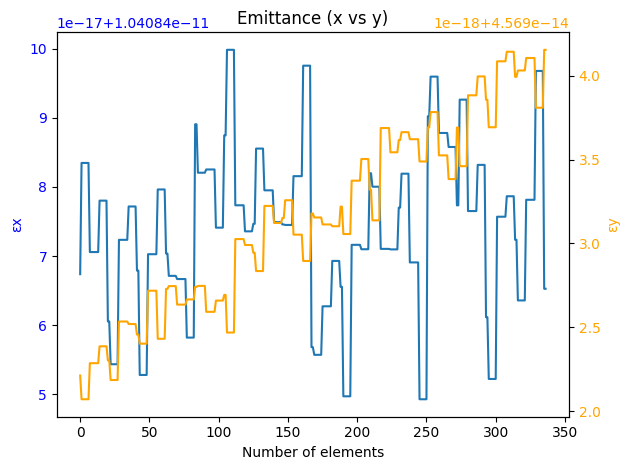

In [240]:
def emitt_calc(X):
    x = X[0,:]
    xp = X[1,:]
    y = X[2,:]
    yp = X[3,:]

    eps_x = np.sqrt(
      np.mean(x**2) * np.mean(xp**2)
      - np.mean(x * xp)**2
    )
    eps_y = np.sqrt(
      np.mean(y**2) * np.mean(yp**2)
      - np.mean(y * yp)**2
    )
    return eps_x, eps_y

tracked_beam = np.array(X_out_beam)

print(tracked_beam.shape)

eps_x_list = []
eps_y_list = []

# only one turn exists
t = 0

for r in range(tracked_beam.shape[2]):

    # (Nparticles, 6)
    X = tracked_beam[:,:,r,t]

    ex, ey = emitt_calc(X)

    eps_x_list.append(ex)
    eps_y_list.append(ey)

eps_x_list = np.array(eps_x_list)
eps_y_list = np.array(eps_y_list)

s = np.arange(len(eps_x_list))

fig, ax1 = plt.subplots()

ax1.plot(s, eps_x_list, label="εx")
ax1.set_xlabel("Number of elements")
ax1.set_ylabel("εx", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

ax2 = ax1.twinx()
ax2.plot(s, eps_y_list, color="orange", label="εy")
ax2.set_ylabel("εy", color="orange")
ax2.tick_params(axis='y', labelcolor="orange")

plt.title("Emittance (x vs y)")
fig.tight_layout()
plt.show()

In [231]:
#@title ##### Generate the particles and track

# Track the particles defined above
global X_out_beam

# Action button to engage tracking
button9 = widgets.Button(description="Track and plot")
output9 = widgets.Output()

display(button9, output9)

# Initialize variables
i=1000 # number of particles

# generate the particles from the rms values above
def on_button_clicked9(b):
    global X_out_beam
    with output9:
      clear_output()

      X2 = np.zeros((6, i))
      X2[0, :] = np.random.normal(0,1,i)*xd.value*1e-3  # particle offset in x
      X2[1, :] = np.random.normal(0,1,i)*xpd.value*1e-3  # particle offset in xp

      X2[2, :] = np.random.normal(0,1,i)*yd.value*1e-3  # particle offset in y
      X2[3, :] = np.random.normal(0,1,i)*ypd.value*1e-3  # particle offset in yp

      X2[4, :] = np.random.normal(0,1,i)*dpd.value*1e-3  # particle offset in yp

      try: # Try if tracking is correct
        # Track the particle in X0 through the lattice.
        X_out_beam = at.lattice_pass(lattice, X2, nturns=1,refpts=refpts)
        # Plot the real space. Show slider to step through the lattice
        interact(plot_rsp, element=widgets.IntSlider(min=0, max=num_of_elem, step=1,value=0));
        # Plot the phase space. Show slider to step through the lattice
        interact(plot_phsp, element=widgets.IntSlider(min=0, max=num_of_elem, step=1,value=0));
      except TypeError:
        print('Error in tracking')

def plot_rsp(element):
  #Plot the real space
  plt.plot(X_out_beam[0,:,element,0],X_out_beam[2,:,element,0],'.')
  axes = plt.gca()
  axes.set_xlabel('x (m)')
  axes.set_ylabel('y (m)')
  axes.set_title('Real space')
  xmin=np.min(X_out_beam[0,:,:,0])
  xmax=np.max(X_out_beam[0,:,:,0])
  if xmin==xmax: # check to not get zero axis length
    xmin=xmin-0.05
    xmax=xmax+0.05
  xmax=np.max([np.abs(xmin),np.abs(xmax)])
  xmin=-xmax

  ymax=np.max(X_out_beam[2,:,:,0])
  ymin=np.min(X_out_beam[2,:,:,0])
  if ymin==ymax: # check to not get zero axis length
    ymin=ymin-0.05
    ymax=ymax+0.05
  ymax=np.max([np.abs(ymin),np.abs(ymax)])
  ymin=-ymax


  axes.set_xlim([xmin,xmax])
  axes.set_ylim([ymin,ymax])
  plt.show()

def plot_phsp(element):
    #Plot phase space x - x'
    plt.figure(figsize=(8,4), dpi= 100, facecolor='w', edgecolor='k')
    plt.subplot(1,2,1)
    plt.plot(X_out_beam[0,:,element,0],X_out_beam[1,:,element,0],'.')
    axes = plt.gca()
    axes.set_xlabel('x (m)')
    axes.set_ylabel('xp (rad)')
    axes.set_title('Horisontal phase space')

    # Find the plot limits
    xmin=np.min(X_out_beam[0,:,:,0])
    xmax=np.max(X_out_beam[0,:,:,0])
    if xmin==xmax: # check to not get errors later
      xmin=xmin-0.05
      xmax=xmax+0.05
    xmax=np.max([np.abs(xmin),np.abs(xmax)])
    xmin=-xmax

    ymax=np.max(X_out_beam[1,:,:,0])
    ymin=np.min(X_out_beam[1,:,:,0])
    if ymin==ymax: # check to not get errors later
      ymin=ymin-0.05
      ymax=ymax+0.05
    ymax=np.max([np.abs(ymin),np.abs(ymax)])
    ymin=-ymax
    axes.set_xlim([xmin,xmax])
    axes.set_ylim([ymin,ymax])

    # Plot phase space y - y'
    plt.subplot(1,2,2)
    plt.plot(X_out_beam[2,:,element,0],X_out_beam[3,:,element,0],'.')
    axes = plt.gca()
    axes.set_xlabel('y (m)')

    # Find the plot limits
    xmin=np.min(X_out_beam[2,:,:,0])
    xmax=np.max(X_out_beam[2,:,:,0])
    if xmin==xmax: # check to not get errors later
      xmin=xmin-0.05
      xmax=xmax+0.05
    xmax=np.max([np.abs(xmin),np.abs(xmax)])
    xmin=-xmax

    ymax=np.max(X_out_beam[3,:,:,0])
    ymin=np.min(X_out_beam[3,:,:,0])
    if ymin==ymax: # check to not get errors later
      ymin=ymin-0.05
      ymax=ymax+0.05
    ymax=np.max([np.abs(ymin),np.abs(ymax)])
    ymin=-ymax
    axes.set_xlim([xmin,xmax])
    axes.set_ylim([ymin,ymax])

    axes.set_title('Vertical phase space')

    plt.show()

button9.on_click(on_button_clicked9)

Button(description='Track and plot', style=ButtonStyle())

Output()

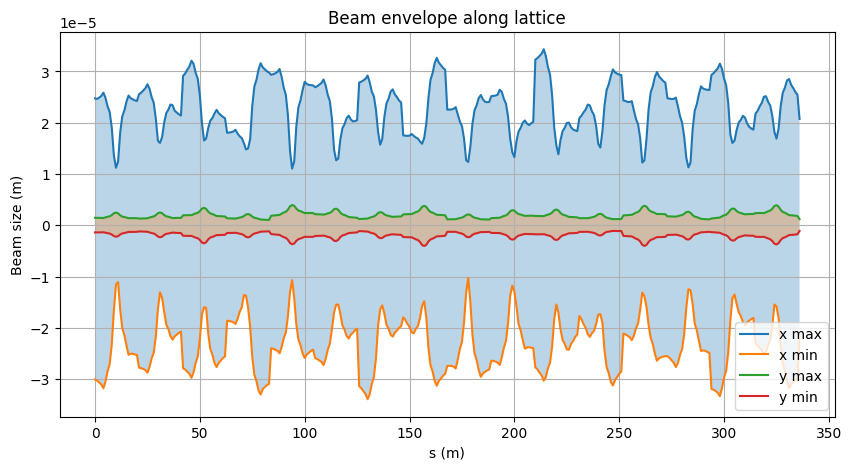

In [237]:

def plot_envelope():

    # współrzędna s
    s_plot = s[:X_out_beam.shape[2]]

    # ===== X envelope =====
    x_max = np.max(X_out_beam[0, :, :, 0], axis=0)
    x_min = np.min(X_out_beam[0, :, :, 0], axis=0)

    # ===== Y envelope =====
    y_max = np.max(X_out_beam[2, :, :, 0], axis=0)
    y_min = np.min(X_out_beam[2, :, :, 0], axis=0)

    plt.figure(figsize=(10,5))

    # X
    plt.plot(s_plot, x_max, label='x max')
    plt.plot(s_plot, x_min, label='x min')

    # Y
    plt.plot(s_plot, y_max, label='y max')
    plt.plot(s_plot, y_min, label='y min')

    # wypełnienie obwiedni
    plt.fill_between(s_plot, x_min, x_max, alpha=0.3)
    plt.fill_between(s_plot, y_min, y_max, alpha=0.3)

    plt.xlabel('s (m)')
    plt.ylabel('Beam size (m)')
    plt.title('Beam envelope along lattice')

    plt.legend()
    plt.grid(True)

    plt.show()


plot_envelope()